In [1]:
# 1. Instalación y Carga de librerías
!pip install gensim

import gensim
from gensim.models import Word2Vec
import nltk
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

nltk.download('punkt')
nltk.download('punkt_tab')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 20.6 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [37]:
# Texto a tokenizar
corpus = [
    "Sistema solar tiene ocho planetas principales",
    "Sol es una estrella de tipo espectral G2",
    "Vía Láctea es la galaxia donde reside la Tierra",
    "Marte es conocido como el planeta rojo y tiene agua congelada",
    "Misiones espaciales buscan vida en otros planetas",
    "Agujeros negros tienen una gravedad tan fuerte que ni la luz escapa",
    "Astronomía estudia los astros y las leyes que rigen el universo"
]

# Preprocesamiento simple: minúsculas y tokenización
tokenized_corpus = [word_tokenize(sentence.lower()) for sentence in corpus]
print("Ejemplo de texto tokenizado:", tokenized_corpus[0])

Ejemplo de texto tokenizado: ['sistema', 'solar', 'tiene', 'ocho', 'planetas', 'principales']


In [70]:
# Entrenamiento del modelo
model = Word2Vec(sentences=tokenized_corpus, vector_size=100, window=5, min_count=1, workers=4)
print("Modelo entrenado exitosamente.")

Modelo entrenado exitosamente.


In [79]:
# Representacion vectorial (embedding) de una palabra específica
word = "planeta"
if word in model.wv:
    print(f"Embedding de '{word}' (primeros 10 valores):\n", model.wv[word][:10])

# Encontrar palabras similares
search = "agujeros"
words_similar = model.wv.most_similar(search, topn=3)
print(f"\nPalabras más similares a '{search}':\n", words_similar)

# Encontrar distancia entre similitud de dos palabras
words_compare = ['solar', 'vida'];
w_coseno = model.wv.similarity(words_compare[0], words_compare[1]);
print(f"\nAproximacion de similitud entre '{words_compare[0]}' y '{words_compare[1]}': {w_coseno}")

Embedding de 'planeta' (primeros 10 valores):
 [-0.00150869 -0.00406463 -0.0044175  -0.00463092 -0.00562517 -0.00531963
 -0.00802932  0.00955104  0.00638359 -0.00362402]

Palabras más similares a 'agujeros':
 [('galaxia', 0.19219107925891876), ('principales', 0.1575171947479248), ('láctea', 0.1563033163547516)]

Aproximacion de similitud entre 'solar' y 'vida': 0.09515251219272614


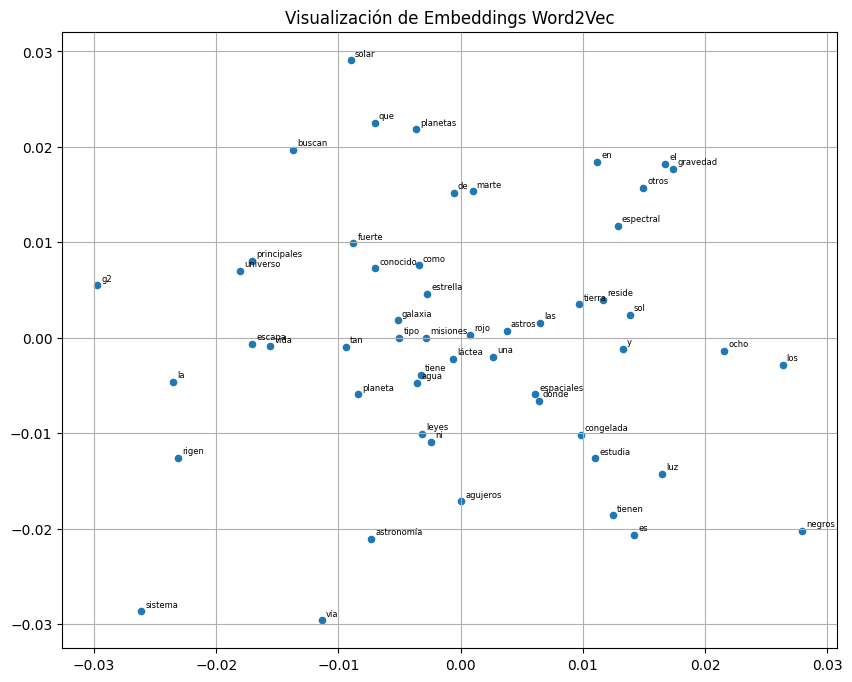

In [112]:
def plot_embeddings(model):
    words = list(model.wv.index_to_key)
    vectors = model.wv[words]

    pca = PCA(n_components=2)
    result = pca.fit_transform(vectors)

    plt.figure(figsize=(10, 8))
    plt.scatter(result[:, 0], result[:, 1], s=20)

    for i, word in enumerate(words):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]), xytext=(3, 3), textcoords="offset points", fontsize=6)

    plt.title("Visualización de Embeddings Word2Vec")
    plt.grid(True)
    plt.show()

plot_embeddings(model)